In [3]:
# Load all 6 pretrained models

from sparseDPD import DataManager, ARVTDNN_NeuralNetwork, Volterra, PNTDNN_NeuralNetwork, PGJANET_NeuralNetwork

# Same dataset/training style as refactored_notebook.ipynb
simpleDataManager = DataManager(
    num_training_points=20000,
    num_validaiton_points=2000,
    num_test_points=2000,
    filepath='UCD_datasets/PA_IO.mat'
)

# Setup a volterra model and a volterra inverse
volterra_forward_model = Volterra(num_nl_orders=3, num_memory_levels=3, dataset=simpleDataManager.training_dataset)

print(f" Volterra NMSE: {volterra_forward_model.calculate_volterra_nmse(simpleDataManager.test_dataset)} dB")

ARVTDNN_one_layer_forward_nn = ARVTDNN_NeuralNetwork(
    num_memory_levels=15,
    forward_model=True,
    model_type = 'OneLayerNetwork',
    nn_file_path = 'pre_trained_models/arvtdnn_one_layer.pt'
)

PGJANET_forward_nn = PGJANET_NeuralNetwork(
    num_memory_levels=50,
    forward_model=True,
    nn_file_path = 'pre_trained_models/pgjanet_checkpoint.pt',
    batch_size=32,
    seq_stride=1
)

PNTDNN_one_layer_forward_nn = PNTDNN_NeuralNetwork(
    num_memory_levels=15,
    forward_model=True,
    nn_file_path = 'pre_trained_models/pntdnn_one_layer.pt'
)

PNTDNN_multi_layer_forward_nn = PNTDNN_NeuralNetwork(
    num_memory_levels=15,
    forward_model=True,
    model_type = 'MultiLayerNetwork',
    nn_file_path = 'pre_trained_models/pntdnn_multi_layer.pt'
)

PNTDNN_three_layer_forward_nn = PNTDNN_NeuralNetwork(
    num_memory_levels=15,
    forward_model=True,
    model_type = 'ThreeLayerNetwork',
    nn_file_path = 'pre_trained_models/pntdnn_three_layer.pt'
)



 Volterra NMSE: -36.75465903237275 dB
Using cuda device
Using cuda device
Using cuda device
Using cuda device
Using cuda device


Baseline NMSE          : -40.0258 dB
Tolerance              : +1.00 dB
NMSE must stay below   : -39.0258 dB
Initial prune fraction : 50.0%
Min prune fraction     : 1.0%
Max prune fraction     : 50.0%

Step 1  |  fraction = 50.00%
Pruning 50.00% of remaining weights...
Current sparsity: 50.00% of weights are zero
Retraining for 200 epochs...
Epoch  10/200  Loss=2.3411e-01  Valid Loss=1.7739e-02  LR=1.00e-03  NMSE=-40.3068 dB
Epoch  20/200  Loss=2.1904e-01  Valid Loss=1.6514e-02  LR=1.00e-03  NMSE=-40.6175 dB
Epoch  30/200  Loss=2.2258e-01  Valid Loss=1.6849e-02  LR=1.00e-03  NMSE=-40.5304 dB
Epoch  40/200  Loss=1.9162e-01  Valid Loss=2.0225e-02  LR=5.00e-04  NMSE=-39.7372 dB
Epoch  50/200  Loss=1.7854e-01  Valid Loss=1.5476e-02  LR=2.50e-04  NMSE=-40.8996 dB
Epoch  60/200  Loss=1.6762e-01  Valid Loss=1.5114e-02  LR=1.25e-04  NMSE=-41.0025 dB
Epoch  70/200  Loss=1.6829e-01  Valid Loss=1.4997e-02  LR=1.25e-04  NMSE=-41.0360 dB
Epoch  80/200  Loss=1.6836e-01  Valid Loss=1.4866e-02  LR=1.25

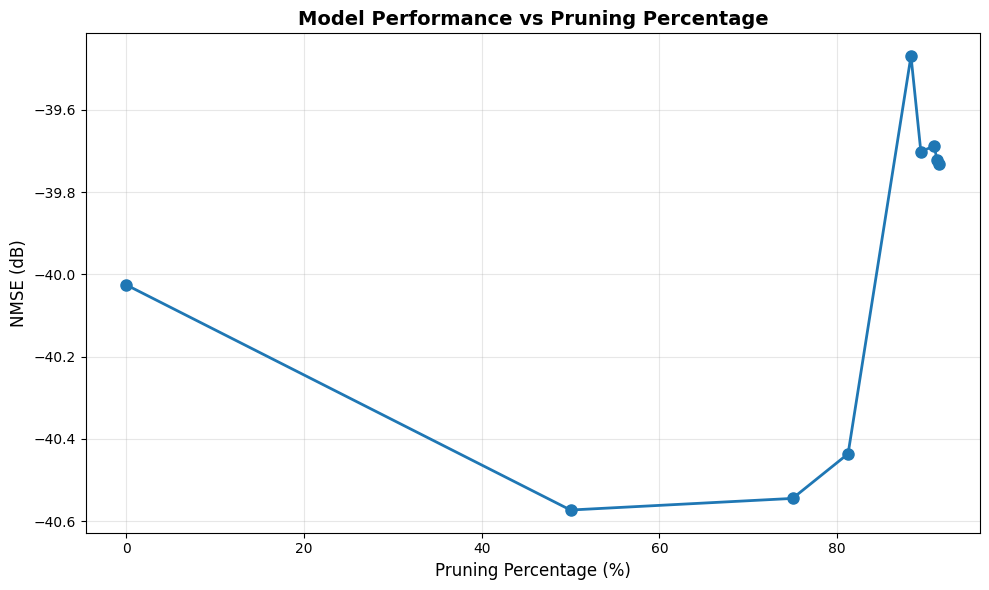

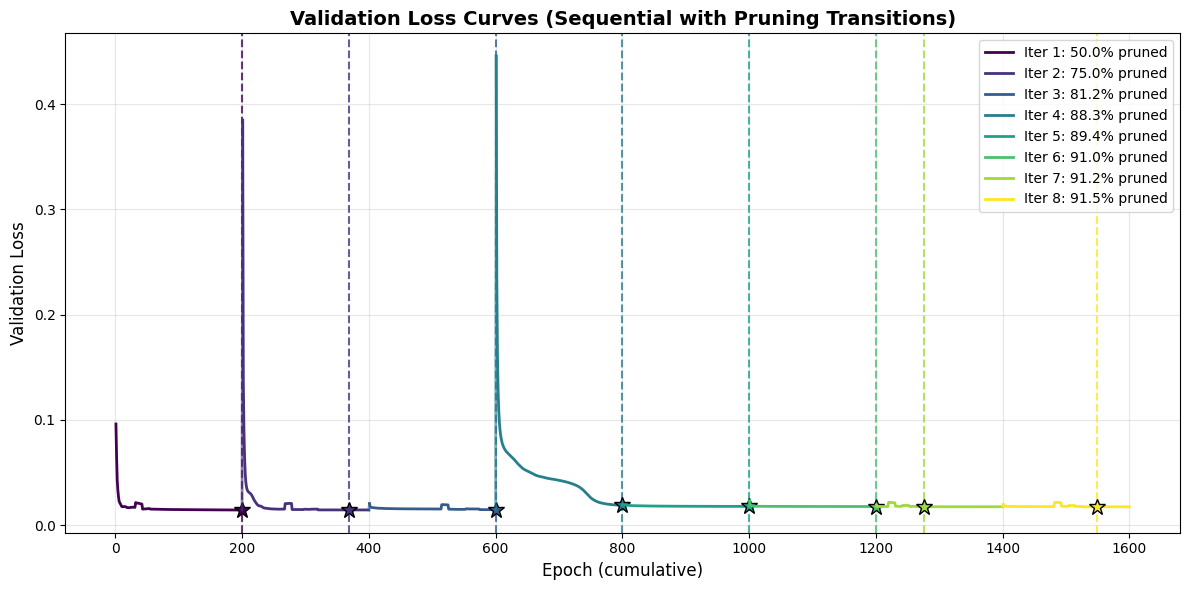

In [2]:
# Use the New Adaptive Pruning Experiment on PNTDNN one layer forward model
from sparseDPD import AdaptivePruningExperiment

adaptive_pruning_experiment = AdaptivePruningExperiment(
    nn_model=PNTDNN_one_layer_forward_nn,
    retrain_epochs= 200,
    training_dataset = simpleDataManager.training_dataset,
    valid_dataset = simpleDataManager.validation_dataset,
    test_dataset = simpleDataManager.test_dataset,
    nmse_tolerance = 1,
    initial_prune_fraction=0.5,
    min_prune_fraction=0.01,
    max_prune_fraction=0.5
)

adaptive_pruning_experiment.run()


In [3]:
# CHeck how many parameters were in the original model

print(f"Original PNTDNN one layer forward model parameters: {PNTDNN_one_layer_forward_nn.get_num_params()*(1-0.8972)}")

Original PNTDNN one layer forward model parameters: 74.016


Baseline NMSE          : -40.9721 dB
Tolerance              : +1.00 dB
NMSE must stay below   : -39.9721 dB
Initial prune fraction : 50.0%
Min prune fraction     : 1.0%
Max prune fraction     : 50.0%

Step 1  |  fraction = 50.00%
Pruning 50.00% of remaining weights...
Current sparsity: 50.00% of weights are zero
Retraining for 35 epochs...
Epoch  10/35  Loss=1.5731e-01  Valid Loss=1.5849e-02  LR=1.00e-03  NMSE=-40.7231 dB
Epoch  20/35  Loss=1.4227e-01  Valid Loss=1.5727e-02  LR=1.00e-03  NMSE=-40.7565 dB
Epoch  30/35  Loss=1.4105e-01  Valid Loss=1.1500e-02  LR=1.00e-03  NMSE=-42.1162 dB

Best model from epoch 35 with validation loss: 1.1415e-02
NMSE: -41.1582 dB  (threshold: -39.9721 dB)
  ACCEPTED  (delta: -0.1860 dB)
  Plenty of headroom -> increasing next fraction to 50.00%

Step 2  |  fraction = 50.00%
Pruning 50.00% of remaining weights...
Current sparsity: 75.00% of weights are zero
Retraining for 35 epochs...
Epoch  10/35  Loss=3.3666e-01  Valid Loss=3.7208e-02  LR=1.00e-03  NMS

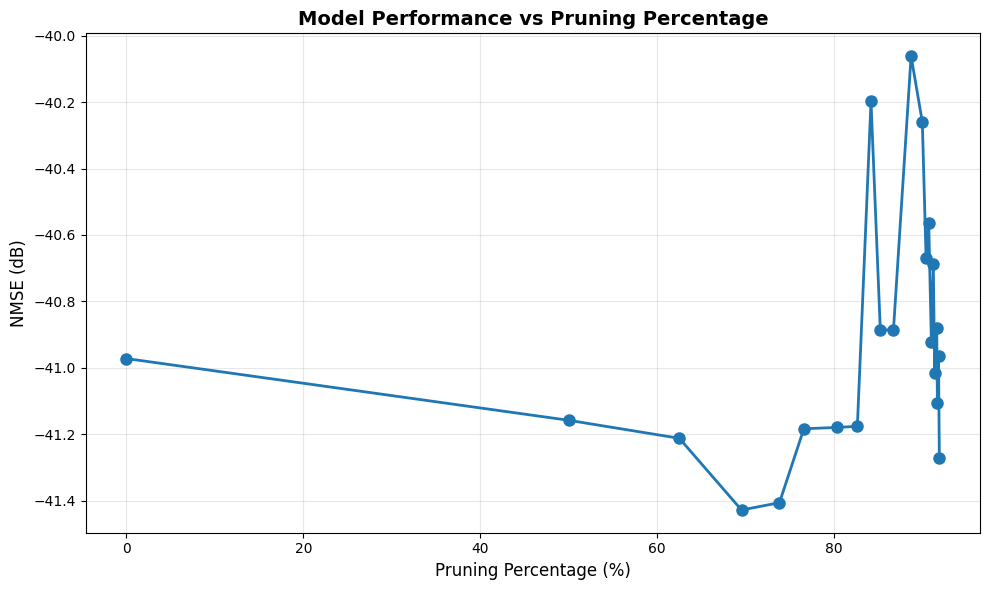

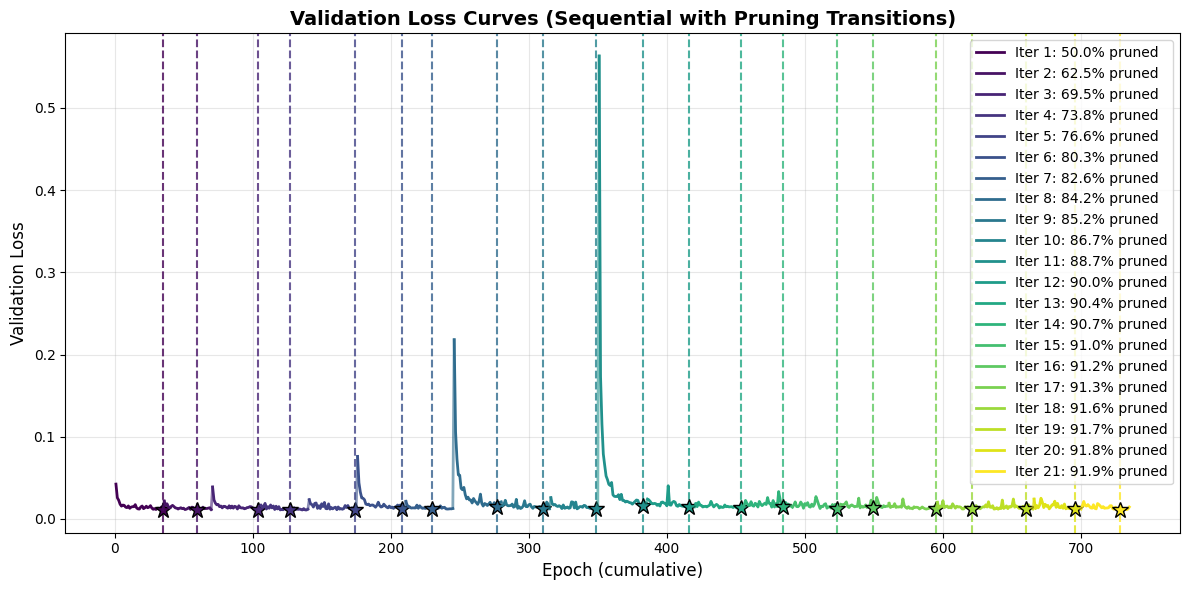

In [4]:
from sparseDPD import AdaptivePruningExperiment

adaptive_pruning_experiment_PJGANET = AdaptivePruningExperiment(
    nn_model=PGJANET_forward_nn,
    retrain_epochs= 35,
    training_dataset = simpleDataManager.training_dataset,
    valid_dataset = simpleDataManager.validation_dataset,
    test_dataset = simpleDataManager.test_dataset,
    nmse_tolerance = 1,
    initial_prune_fraction=0.5,
    min_prune_fraction=0.01,
    max_prune_fraction=0.5
)

adaptive_pruning_experiment_PJGANET.run()